In [1]:
from fiatlux.optical_elements.mask import CircularAperture
from fiatlux.grid import Grid
from fiatlux.spectrum import *
from fiatlux.source import *
from fiatlux.propagator import MFTPropagator
from fiatlux.optical_elements.mask import ZeldaMask, ZeldaStop
from fiatlux.utils.converter import FocalPlaneConverter
from fiatlux.optical_elements.field_stop import ShanonFieldStop

from fiatlux.optical_elements.deformable_mirror import (
    DeformableMirror,
    ActuatorGrid,
    InteractionMatrix,
)

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
spectrum = Spectrum.from_sampling(PhotometricBand.I4, Nu=512)

# System parameters
f = 0.125
lambda_max = spectrum.wavelengths.max()
D = 10

# Pupil plane sampling
Nx = Ny = 128
dx = dy = D / Nx
pupil_grid = Grid(nx=Nx, ny=Ny, dx=dx, dy=dx)

# Focal plane sampling
Nu = Nv = 512
# # Shanon
# du = dv = Nx * (f * l / D) / Nu
du = dv = (Nx / 2) * (f * lambda_max / D) / (Nu / 2)
focal_grid = Grid(nx=Nu, ny=Nv, dx=du, dy=dv)

# Create source
source = PlaneWave(spectrum=spectrum)

# Create aperture
aperture = CircularAperture(radius=D / 2)

# Define propagator
mft = MFTPropagator(focal_length=f)

stop = ShanonFieldStop()

TypeError: MFTPropagator.__init__() missing 1 required positional argument: 'output_grid'

/Users/pjanin/Documents/GitHub/fiatlux/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


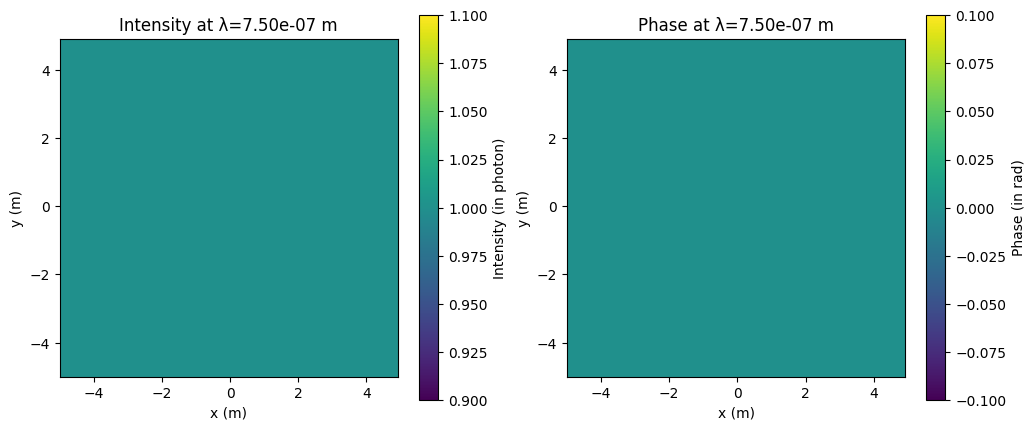

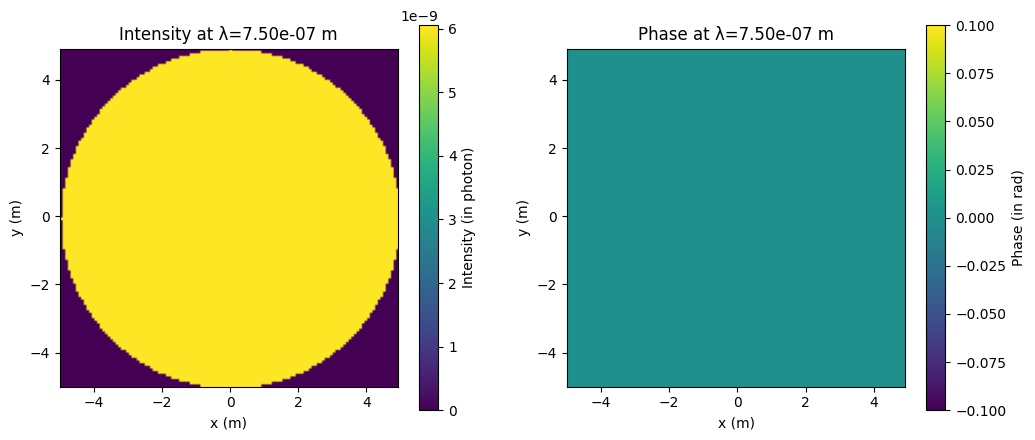

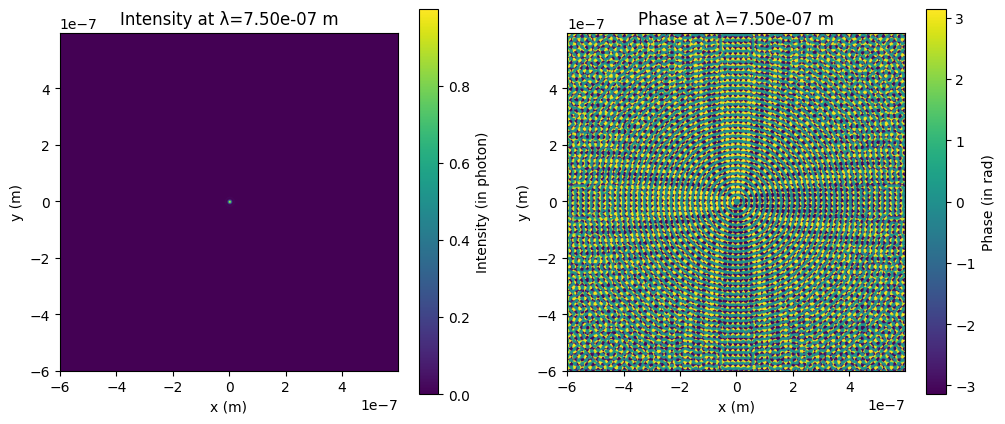

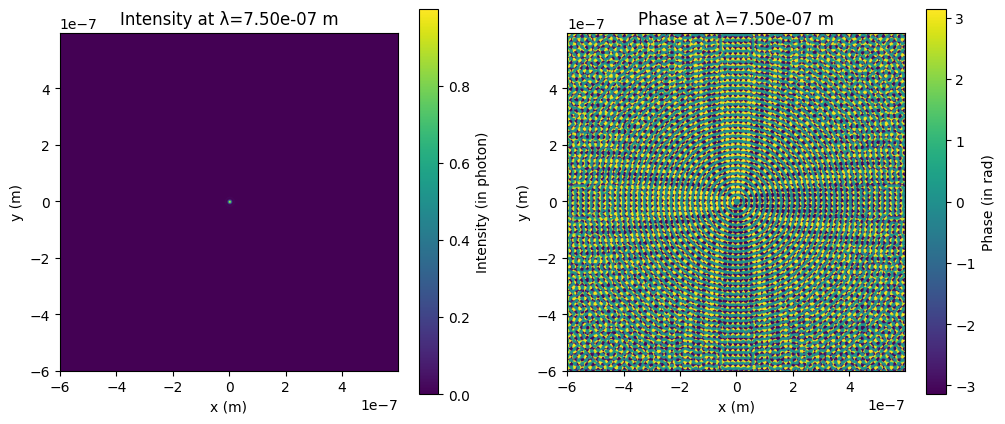

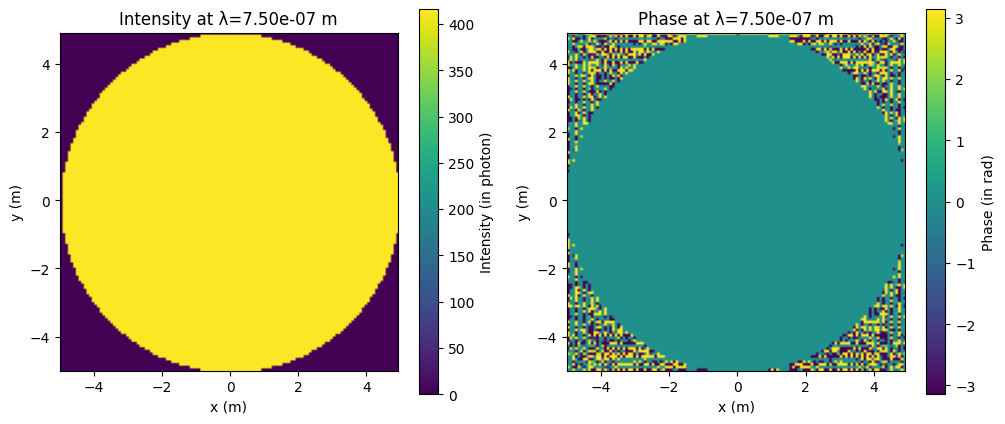

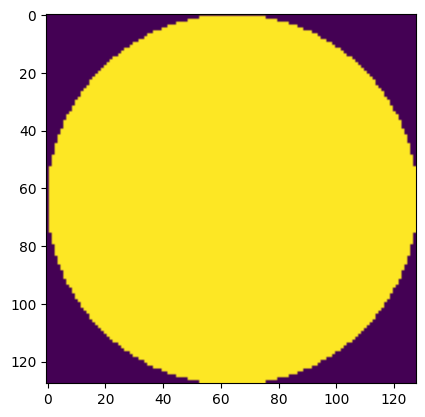

In [ ]:
field = source.generate_field(grid=pupil_grid)
field.plot()

field = aperture.apply(field)
field.plot()

field = mft.propagate(field, output_grid=focal_grid)
field.plot()

field = stop.apply(field)
field.plot()

field = mft.propagate(field, output_grid=pupil_grid)
field.plot()

plt.figure()
plt.imshow(field.intensity()[0])